

---
# **Handwritten Digit Classification using ANN**

##1. Import Required Libraries

In [45]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten
import matplotlib.pyplot as plt

##2. Load the MNIST Dataset

The MNIST dataset contains handwritten digit images from 0 to 9. The dataset is divided into training and testing sets, where X contains the images and y contains their corresponding labels.

In [46]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

##3. Explore the Dataset


We inspect the shape of the dataset to understand the number of images and the dimensions of each image.

In [47]:
X_train.shape

(60000, 28, 28)

In [48]:
X_test.shape

(10000, 28, 28)

In [49]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

##4. Visualize Sample Images


Sample images are visualized to understand the handwritten digits in the dataset.

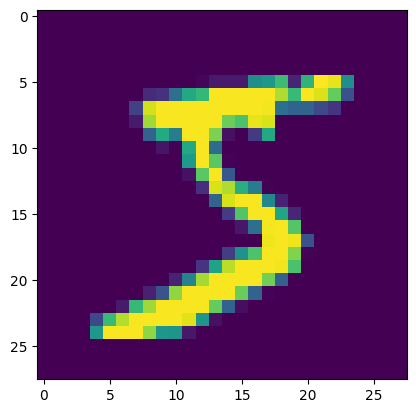

In [50]:
plt.imshow(X_train[0])

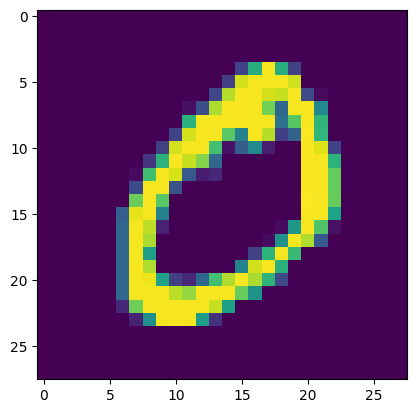

In [51]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1])

##5. Data Preprocessing


Pixel values range from 0 to 255. Dividing by 255 normalizes them to a range between 0 and 1, making the data suitable for neural network training.

In [52]:
# normalize the pixel values
X_train = X_train/255
X_test = X_test/255

## 6. Build the ANN Model


A Sequential neural network is built by adding layers one after another.

In [53]:
model = Sequential()


Each image is 28×28 pixels. The Flatten layer converts it into a 784-value one-dimensional vector for the ANN.

In [54]:
# Flatten Layer
model.add(Flatten(input_shape=(28,28)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Two fully connected hidden layers with 32 and 128 neurons use ReLU activation to learn patterns from the input data.

In [55]:
# Hidden layers
model.add(Dense(32,activation='relu'))
model.add(Dense(128,activation='relu'))

The output layer has 10 neurons, representing digits 0–9. Softmax produces a probability for each class.

In [56]:
# output layer
model.add(Dense(10,activation='softmax'))

## 7. Model Summary


The model summary shows the network architecture, output shapes, and trainable parameters.

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,634 (119.66 KB)

 Trainable params: 30,634 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the Model


The model is compiled using Adam as the optimizer, sparse categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

In [58]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

## 9. Train the Model


The model is trained for 25 epochs, with 20% of the training data used for validation.

In [59]:
history = model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9050 - loss: 0.3319 - val_accuracy: 0.9498 - val_loss: 0.1734
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9540 - loss: 0.1553 - val_accuracy: 0.9583 - val_loss: 0.1397
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9656 - loss: 0.1150 - val_accuracy: 0.9585 - val_loss: 0.1378
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9720 - loss: 0.0939 - val_accuracy: 0.9676 - val_loss: 0.1097
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9747 - loss: 0.0808 - val_accuracy: 0.9696 - val_loss: 0.1074
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9789 - loss: 0.0698 - val_accuracy: 0.9697 - val_loss: 0.1054
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9800 - loss: 0.0616 - val_accuracy: 0.9673 - val_loss: 0.1223
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9824 - loss: 0.0541 - 

## 10. Model Evaluation


The trained model generates class probabilities for each image in the test dataset.

In [60]:
# generate predictions
y_prob = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


`argmax()` selects the class with the highest predicted probability as the final digit prediction.

In [61]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

Test accuracy is calculated by comparing the predicted labels with the actual test labels.

In [62]:
# Calculate Accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.9735

The ANN achieved 97.35% accuracy on the test dataset.

## 11. Training Performance


Training and validation loss are plotted to observe how the model's error changes across epochs.

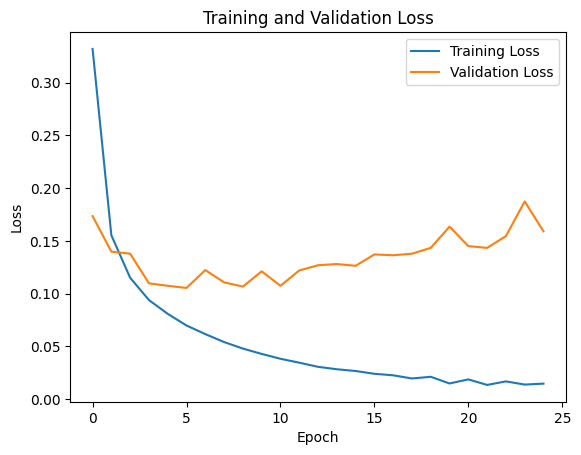

In [63]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

Training and validation accuracy are plotted to observe the model's performance across epochs.

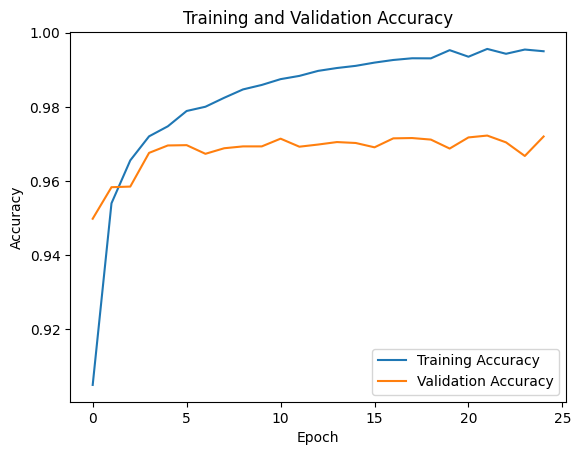

In [64]:
 # Accuracy Curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

## 12. Individual Image Predictions


The trained model is tested on individual images to verify its digit predictions.

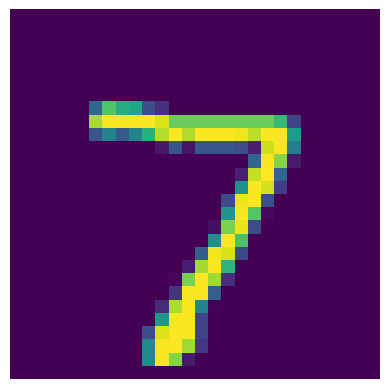

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted digit: 7
Actual digit: 7


In [65]:
plt.imshow(X_test[0])
plt.axis('off')
plt.show()

prediction = model.predict(X_test[0].reshape(1, 28, 28)).argmax(axis=1)

print("Predicted digit:", prediction[0])
print("Actual digit:", y_test[0])

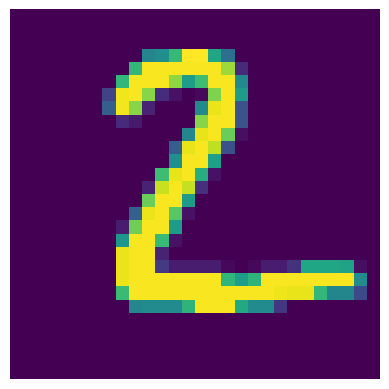

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted digit: 2
Actual digit: 2


In [66]:
plt.imshow(X_test[1])
plt.axis('off')
plt.show()

prediction = model.predict(X_test[1].reshape(1, 28, 28)).argmax(axis=1)

print("Predicted digit:", prediction[0])
print("Actual digit:", y_test[1])

## 13. Conclusion

An Artificial Neural Network was developed to classify handwritten digits from the MNIST dataset. The model uses a Flatten layer followed by two fully connected hidden layers with ReLU activation and a 10-class Softmax output layer. After training for 25 epochs, the model achieved 97.35% accuracy on the test dataset.